ASSIGNMENT 1
Understanding Generative and Discriminative Models Using MNIST

Objective
The objective of this assignment is to understand the basic difference between a
discriminative model and a generative model by working with a simple dataset of
handwritten digits.

What You Need to Do
In this assignment, you will use the MNIST dataset and select only the images representing
the digits 0 and 1.
First, build a simple discriminative model, such as Logistic Regression or a small neural
network. Train the model to identify whether a given image represents the digit 0 or 1.
Record the accuracy achieved by your model.
Next, build a simple generative model, such as a basic Autoencoder. Use this model to learn
the patterns present in the digit images and generate new examples of digits 0 and 1.
Finally, compare the two approaches in the same notebook.

Your Notebook Should Include
• The dataset preparation process
• A discriminative model for classifying 0 and 1
• Accuracy of the discriminative model
• A simple generative model
• Examples of newly generated digit images
• A visual comparison of real images, predictions, and generated images

Written Reflection
Write 4–5 lines in your own words explaining:
• What did the discriminative model learn?
• What did the generative model learn?
• How are the two approaches different?

Submission
Submit a Jupyter Notebook or Google Colab Notebook containing your code, outputs,
generated images, and written comparison.

Focus: The purpose is to understand the difference between learning a decision boundary
and learning a data distribution. The generative model does not need to be highly complex.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Reshape
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [2]:
#Loading the dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training images:", X_train.shape)
print("Testing images:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)


In [3]:
# Selecting only images of digits 0 and 1
train_mask = (y_train == 0) | (y_train == 1)
test_mask = (y_test == 0) | (y_test == 1)

X_train_01 = X_train[train_mask]
y_train_01 = y_train[train_mask]

X_test_01 = X_test[test_mask]
y_test_01 = y_test[test_mask]

print("Training data:", X_train_01.shape)
print("Testing data:", X_test_01.shape)
print("Classes:", np.unique(y_train_01))

Training data: (12665, 28, 28)
Testing data: (2115, 28, 28)
Classes: [0 1]


In [4]:
# Normalizing pixel values
X_train_01 = X_train_01.astype("float32") / 255.0
X_test_01 = X_test_01.astype("float32") / 255.0

print("Minimum pixel value:", X_train_01.min())
print("Maximum pixel value:", X_train_01.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


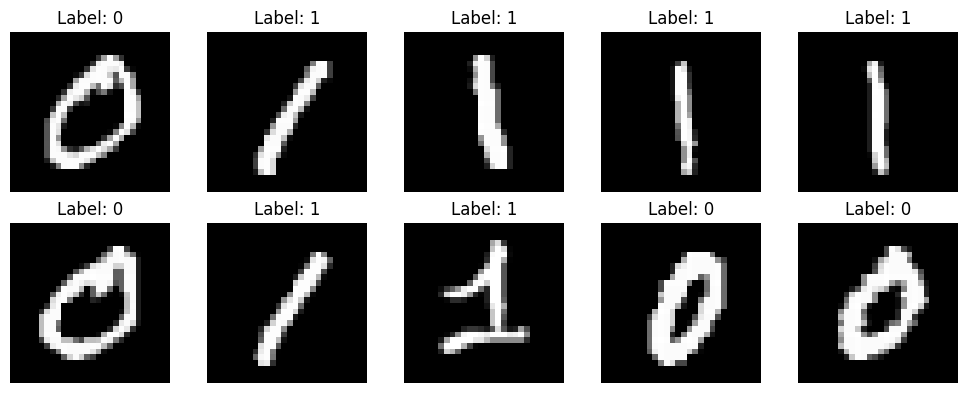

In [5]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train_01[i], cmap="gray")
    plt.title(f"Label: {y_train_01[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# **Discriminative Model**

In [6]:
# Flatten 28x28 images into 784-dimensional vectors
X_train_flat = X_train_01.reshape(X_train_01.shape[0], -1)
X_test_flat = X_test_01.reshape(X_test_01.shape[0], -1)

print("Training shape:", X_train_flat.shape)
print("Testing shape:", X_test_flat.shape)

Training shape: (12665, 784)
Testing shape: (2115, 784)


In [8]:
# Creating Logistic Regression model
discriminative_model = LogisticRegression(
    max_iter=1000
)

#Model Training
discriminative_model.fit(X_train_flat, y_train_01)

LogisticRegression(max_iter=1000)

In [9]:
# Predicting test images
y_pred = discriminative_model.predict(X_test_flat)

accuracy = accuracy_score(y_test_01, y_pred)

print(f"Discriminative Model Accuracy: {accuracy * 100:.2f}%")

Discriminative Model Accuracy: 99.95%


In [10]:
print(classification_report(y_test_01, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      1.00      1.00      1135

    accuracy                           1.00      2115
   macro avg       1.00      1.00      1.00      2115
weighted avg       1.00      1.00      1.00      2115



# **Visualizing**

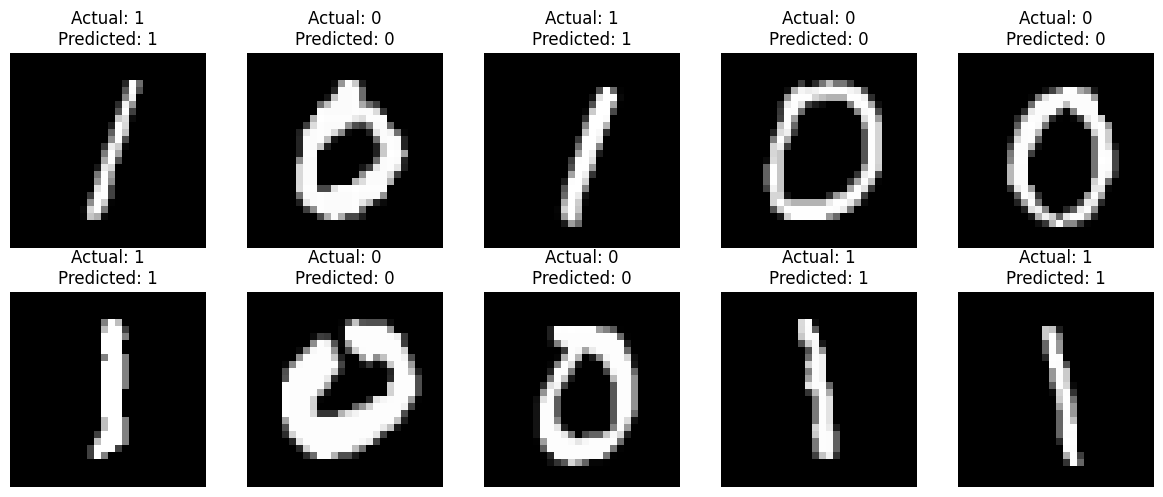

In [11]:
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test_01[i], cmap="gray")
    plt.title(f"Actual: {y_test_01[i]}\nPredicted: {y_pred[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# **Generative Model — Autoencoder**
A basic Autoencoder consists of:

Input Image
     ↓
 Encoder
     ↓
Latent Representation
     ↓
 Decoder
     ↓
Reconstructed Image

In [12]:
# Combine training and testing images for the generative model
X_autoencoder = np.concatenate([X_train_01, X_test_01], axis=0)

print("Autoencoder dataset:", X_autoencoder.shape)

Autoencoder dataset: (14780, 28, 28)


In [13]:
autoencoder = Sequential([

    # Encoder
    Flatten(input_shape=(28, 28)),
    Dense(128, activation="relu"),
    Dense(32, activation="relu"),

    # Decoder
    Dense(128, activation="relu"),
    Dense(784, activation="sigmoid"),
    Reshape((28, 28))
])

autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy"
)

autoencoder.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = autoencoder.fit(
    X_autoencoder,
    X_autoencoder,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    shuffle=True
)

Epoch 1/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.2449 - val_loss: 0.1360
Epoch 2/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1252 - val_loss: 0.1137
Epoch 3/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1087 - val_loss: 0.1019
Epoch 4/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0986 - val_loss: 0.0927
Epoch 5/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0912 - val_loss: 0.0876
Epoch 6/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0866 - val_loss: 0.0838
Epoch 7/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0830 - val_loss: 0.0808
Epoch 8/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0804 - val_loss: 0.0788
Epoch 9/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0783 - val_loss: 0.0771
Epoch 10/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0765 - val_loss: 0.0757
Epoch 11/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0753 - val_loss: 0.0743
Epoch 12/20
104/104 ━━━━━━━━━━━━━━━━━━━━ 

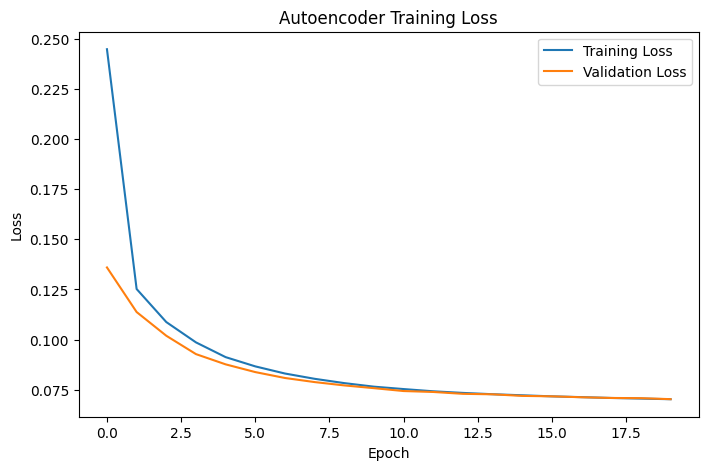

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Training Loss")
plt.legend()
plt.show()

# **Generate/Reconstruct Digit Images**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


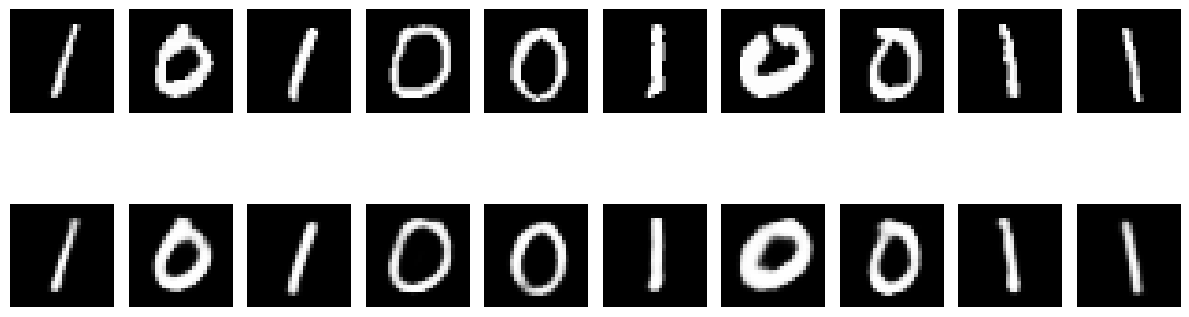

In [16]:
# Select some test images
sample_images = X_test_01[:10]

# Reconstruct them
reconstructed_images = autoencoder.predict(sample_images)

plt.figure(figsize=(12, 5))

for i in range(10):

    # Original
    plt.subplot(2, 10, i + 1)
    plt.imshow(sample_images[i], cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.ylabel("Real", fontsize=12)

    # Reconstructed
    plt.subplot(2, 10, i + 11)
    plt.imshow(reconstructed_images[i], cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.ylabel("Reconstructed", fontsize=12)

plt.tight_layout()
plt.show()

# **Generate New Images From the Latent Space**

In [18]:
encoder = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation="relu"),
    Dense(32, activation="relu")
])

# Copy trained encoder weights
encoder.layers[0].set_weights(autoencoder.layers[0].get_weights())
encoder.layers[1].set_weights(autoencoder.layers[1].get_weights())
encoder.layers[2].set_weights(autoencoder.layers[2].get_weights())


# Decoder
decoder = Sequential([
    Dense(128, activation="relu", input_shape=(32,)), # Added input_shape to build the layer
    Dense(784, activation="sigmoid"),
    Reshape((28, 28))
])

# Copy trained decoder weights
decoder.layers[0].set_weights(autoencoder.layers[3].get_weights())
decoder.layers[1].set_weights(autoencoder.layers[4].get_weights())

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
# Encode some real images
latent_vectors = encoder.predict(X_autoencoder[:1000])

# Calculate the mean and standard deviation of the latent space
latent_mean = np.mean(latent_vectors, axis=0)
latent_std = np.std(latent_vectors, axis=0)

# Generate random latent vectors
random_latent_vectors = np.random.normal(
    loc=latent_mean,
    scale=latent_std,
    size=(10, 32)
)

# Decode the random latent vectors
generated_images = decoder.predict(random_latent_vectors)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step


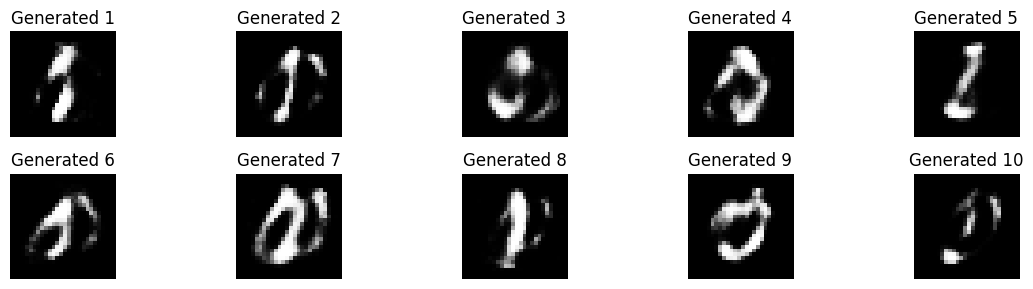

In [20]:
plt.figure(figsize=(12, 3))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(generated_images[i], cmap="gray")
    plt.title(f"Generated {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# **Final Visual Comparison**

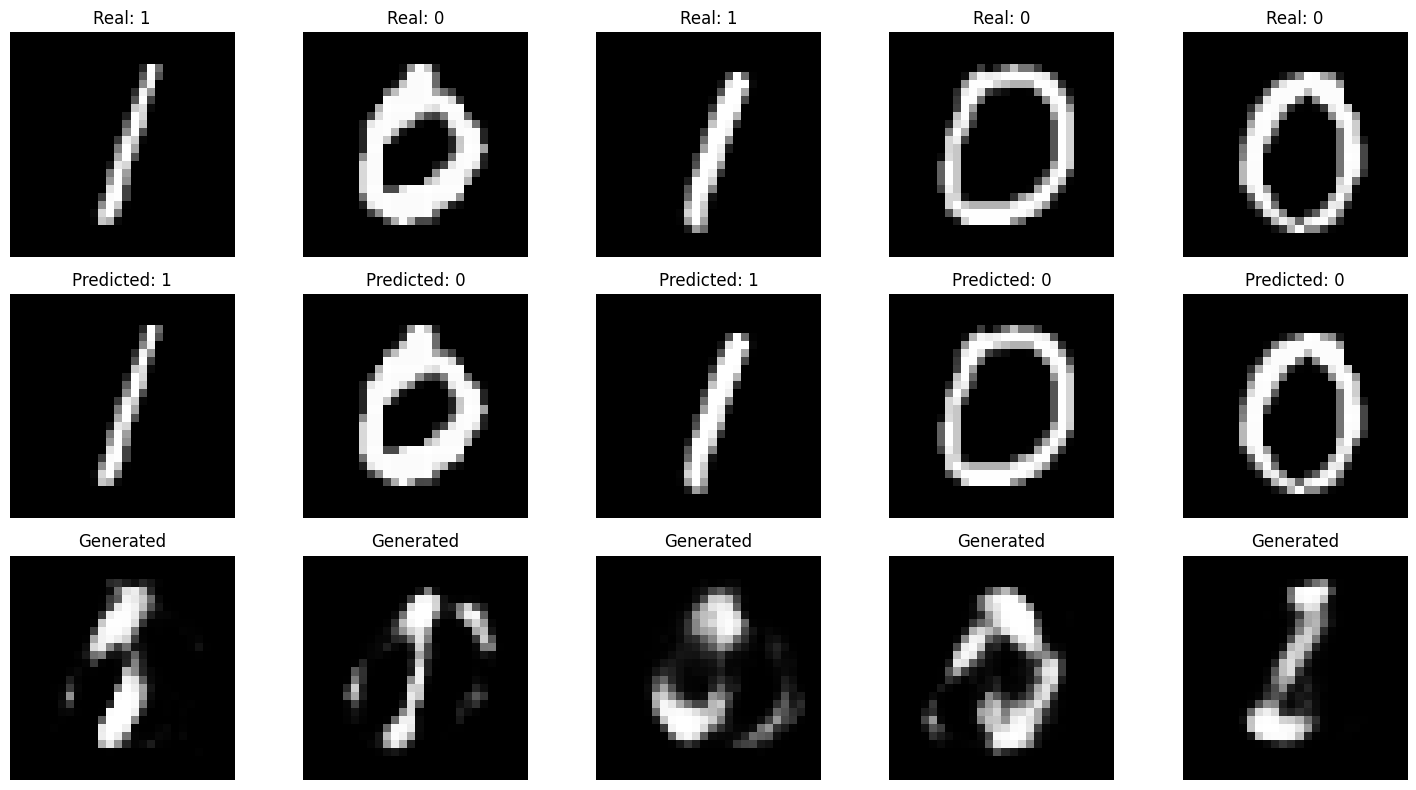

In [21]:
plt.figure(figsize=(15, 8))

# Real images
for i in range(5):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_test_01[i], cmap="gray")
    plt.title(f"Real: {y_test_01[i]}")
    plt.axis("off")

# Predictions
for i in range(5):
    plt.subplot(3, 5, i + 6)
    plt.imshow(X_test_01[i], cmap="gray")
    plt.title(f"Predicted: {y_pred[i]}")
    plt.axis("off")

# Generated images
for i in range(5):
    plt.subplot(3, 5, i + 11)
    plt.imshow(generated_images[i], cmap="gray")
    plt.title("Generated")
    plt.axis("off")

plt.tight_layout()
plt.show()

**The discriminative model learned the important features that distinguish handwritten digits 0 and 1 and used these features to create a decision boundary between the two classes.**

**The generative model learned the general patterns and structure present in the digit images, allowing it to reconstruct and generate images that resemble the original data.**

**The main difference is that the discriminative model focuses on predicting the correct class, while the generative model focuses on learning the underlying data distribution.**

**Therefore, the discriminative model answers “which class does this image belong to?”, while the generative model learns “what do images from this dataset look like?”**